# 🎓 Campus Recruitment: Student Placement Prediction
<div style='background-color:#E9F7EF; padding:15px; border-radius:10px;'>
<b>Problem Statement:</b> A university's placement cell wants to predict which students are likely to be placed in campus recruitment based on academic and employability factors. <br>
<b>Business Objective:</b> Build a classification model that predicts placement status so the placement cell can proactively support students who are less likely to be placed. <br>
<b>Why This Project Matters:</b> This project mirrors real placement-cell analytics used by colleges and training institutes and gives direct, personally relevant insight into what factors employers value.
</div>


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

## 2. Load and Inspect the Dataset

In [2]:
# Load dataset
data_path = '../Dataset/Placement_Data_Full_Class.csv'
df = pd.read_csv(data_path)

# Inspect head
display(df.head())

# Inspect columns and data types
display(df.info())

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 35.0 KB


None

## 3. Data Cleaning

In [3]:
# Check missing values
print("Missing Values before cleaning:\n", df.isnull().sum())

# Drop 'salary' as it leaks target information (only exists for placed students)
if 'salary' in df.columns:
    df = df.drop(columns=['salary'])

# Drop identifier column 'sl_no'
if 'sl_no' in df.columns:
    df = df.drop(columns=['sl_no'])
    
# Drop unencoded strings that are not in scope
if 'ssc_b' in df.columns:
    df = df.drop(columns=['ssc_b'])
if 'hsc_b' in df.columns:
    df = df.drop(columns=['hsc_b'])

# Confirm percentage columns fall within 0-100
perc_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
for col in perc_cols:
    df[col] = df[col].clip(lower=0, upper=100)

# Standardize category text across categorical columns to title case
cat_cols = ['gender', 'workex', 'specialisation']
for col in cat_cols:
    df[col] = df[col].str.title()

print("\nMissing Values after cleaning:\n", df.isnull().sum())
print("\nRemaining Columns:\n", df.columns.tolist())

Missing Values before cleaning:
 sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

Missing Values after cleaning:
 gender            0
ssc_p             0
hsc_p             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64

Remaining Columns:
 ['gender', 'ssc_p', 'hsc_p', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status']


## 4. Exploratory Data Analysis (EDA)

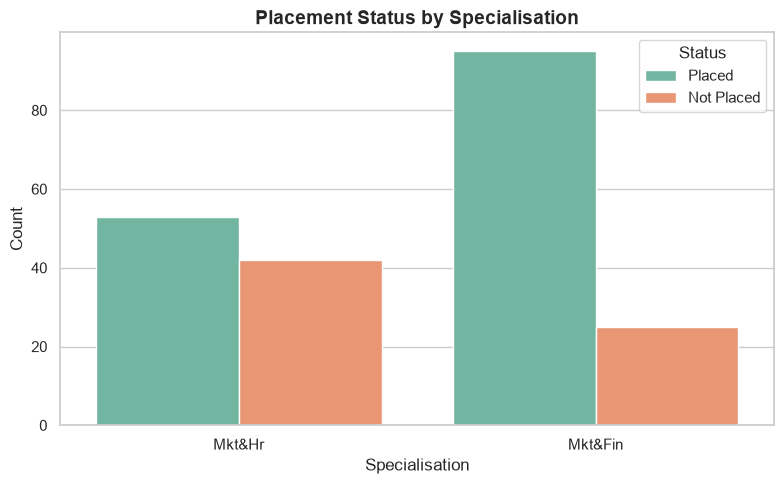

In [4]:
# 4.1 Placement rate by Specialisation
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='specialisation', hue='status', palette='Set2')
plt.title('Placement Status by Specialisation', fontsize=14, fontweight='bold')
plt.xlabel('Specialisation')
plt.ylabel('Count')
plt.legend(title='Status')
plt.tight_layout()
plt.savefig('../Images/placement_by_specialisation.png', dpi=300)
plt.show()

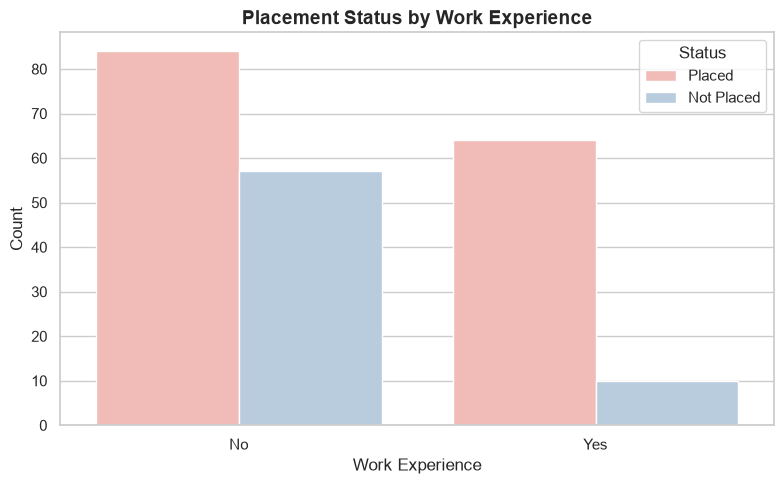

In [5]:
# 4.2 Placement rate by Work Experience
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='workex', hue='status', palette='Pastel1')
plt.title('Placement Status by Work Experience', fontsize=14, fontweight='bold')
plt.xlabel('Work Experience')
plt.ylabel('Count')
plt.legend(title='Status')
plt.tight_layout()
plt.savefig('../Images/placement_by_workex.png', dpi=300)
plt.show()

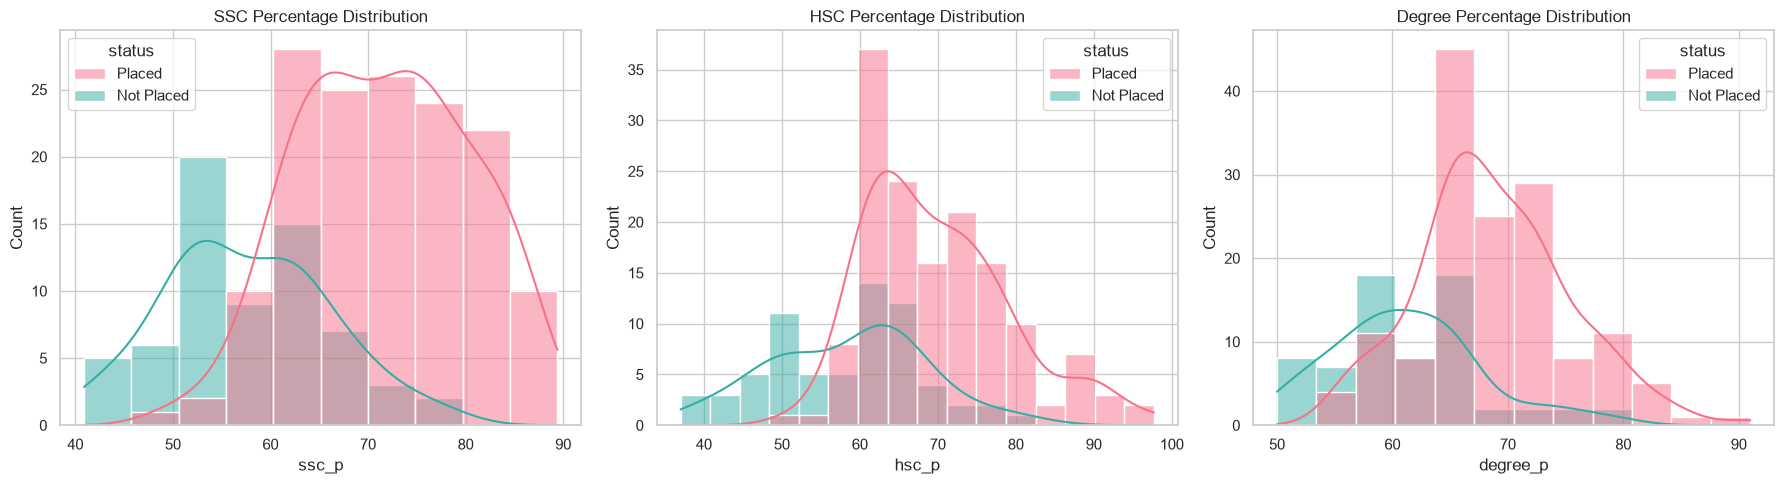

In [6]:
# 4.3 Distribution of Academic Scores split by Placement Status
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df, x='ssc_p', hue='status', kde=True, ax=axes[0], palette='husl')
axes[0].set_title('SSC Percentage Distribution')

sns.histplot(data=df, x='hsc_p', hue='status', kde=True, ax=axes[1], palette='husl')
axes[1].set_title('HSC Percentage Distribution')

sns.histplot(data=df, x='degree_p', hue='status', kde=True, ax=axes[2], palette='husl')
axes[2].set_title('Degree Percentage Distribution')

plt.tight_layout()
plt.savefig('../Images/academic_scores_distribution.png', dpi=300)
plt.show()

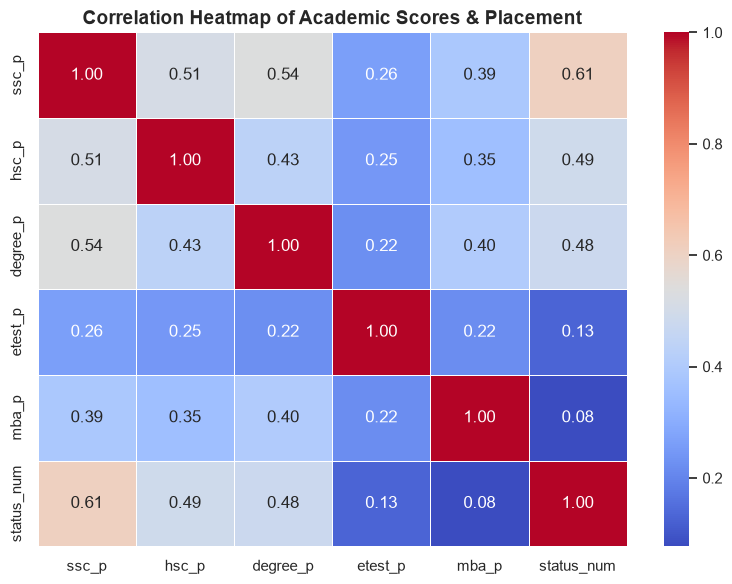

In [7]:
# 4.4 Correlation heatmap of numeric scores against placement
# First, temporarily encode status to numerical for correlation
temp_df = df.copy()
temp_df['status_num'] = temp_df['status'].map({'Placed': 1, 'Not Placed': 0})
num_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'status_num']

plt.figure(figsize=(8,6))
sns.heatmap(temp_df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Academic Scores & Placement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Images/correlation_heatmap.png', dpi=300)
plt.show()

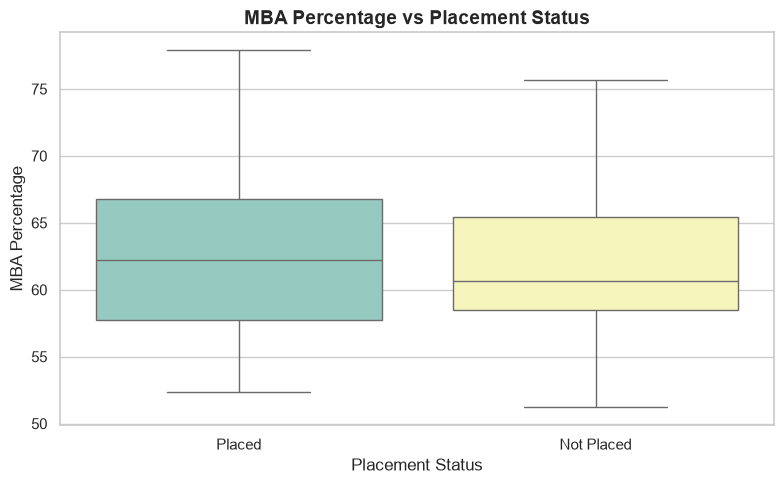

In [8]:
# 4.5 MBA Score vs Placement
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='status', y='mba_p', palette='Set3')
plt.title('MBA Percentage vs Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Placement Status')
plt.ylabel('MBA Percentage')
plt.tight_layout()
plt.savefig('../Images/mba_vs_placement.png', dpi=300)
plt.show()

## 5. Feature Engineering

In [9]:
# Create academic_average feature
df['academic_average'] = df[['ssc_p', 'hsc_p', 'degree_p']].mean(axis=1)

# Encode binary variables (status and gender) manually
df['status'] = df['status'].map({'Placed': 1, 'Not Placed': 0})
# For gender, wait... requirement says one-hot encode gender, hsc_s, degree_t, workex, and specialisation
# Create a binary flag for work experience if not already binary (it's Yes/No, one-hot will handle it nicely, but we can do it explicitly)
df['workex_flag'] = df['workex'].map({'Yes': 1, 'No': 0})

# One-hot encode specified columns
cols_to_encode = ['gender', 'hsc_s', 'degree_t', 'workex', 'specialisation']
df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

print("Features after engineering:\n", df_encoded.columns.tolist())

Features after engineering:
 ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'status', 'academic_average', 'workex_flag', 'gender_M', 'hsc_s_Commerce', 'hsc_s_Science', 'degree_t_Others', 'degree_t_Sci&Tech', 'workex_Yes', 'specialisation_Mkt&Hr']


## 6. Model Building

In [10]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=['status'])
y = df_encoded['status']

# Split into training and test sets (80/20), stratified by status
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

# Train a LogisticRegression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Generate predictions
y_pred = log_reg.predict(X_test)

Training shape: (172, 14)
Testing shape: (43, 14)


## 7. Evaluation

Accuracy:  0.8372
Precision: 0.9259
Recall:    0.8333
F1 Score:  0.8772

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.85      0.76        13
           1       0.93      0.83      0.88        30

    accuracy                           0.84        43
   macro avg       0.81      0.84      0.82        43
weighted avg       0.85      0.84      0.84        43



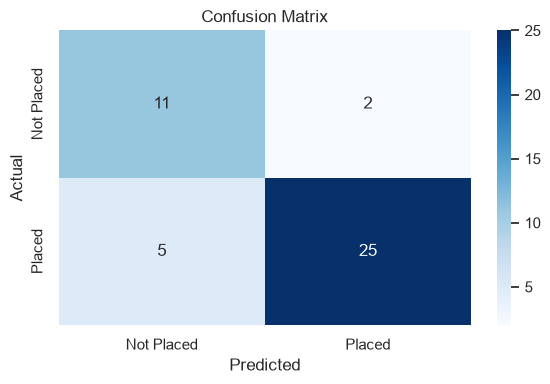

In [11]:
# Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}\n")

print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../Images/confusion_matrix.png', dpi=300)
plt.show()

## 8. Identifying Top Predictors & Generating Recommendations

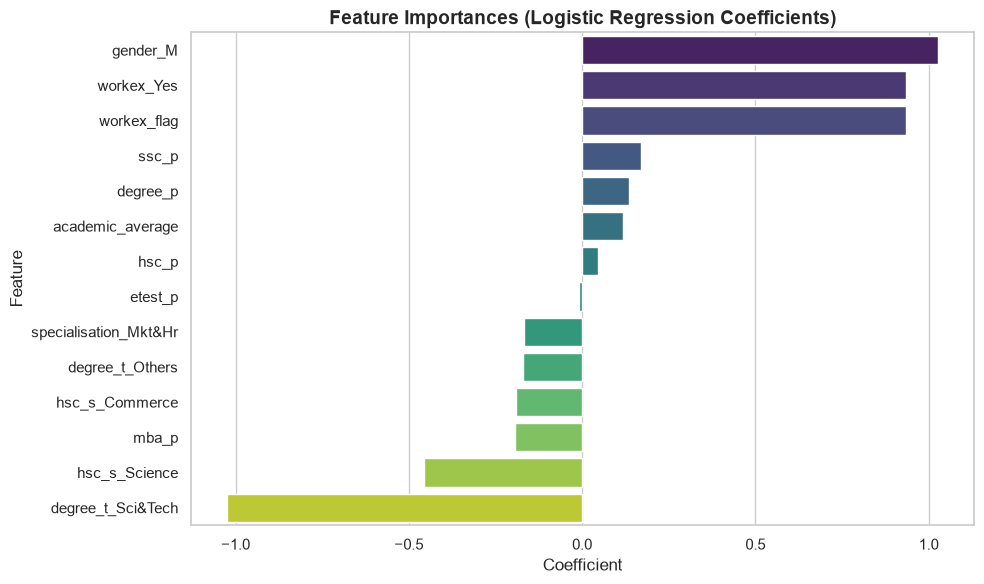

Top Positive Predictors for Placement:


,Feature,Coefficient
7,gender_M,1.028038
12,workex_Yes,0.935237
6,workex_flag,0.935237
0,ssc_p,0.170323
2,degree_p,0.133980



Top Negative Predictors for Placement:


,Feature,Coefficient
10,degree_t_Others,-0.170687
8,hsc_s_Commerce,-0.189858
4,mba_p,-0.194174
9,hsc_s_Science,-0.455519
11,degree_t_Sci&Tech,-1.024805


In [12]:
# Print sorted coefficients to identify the strongest predictors
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette='viridis')
plt.title('Feature Importances (Logistic Regression Coefficients)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Images/feature_importances.png', dpi=300)
plt.show()

print("Top Positive Predictors for Placement:")
display(coefficients.head(5))

print("\nTop Negative Predictors for Placement:")
display(coefficients.tail(5))

<div style='background-color:#EBF5FB; padding:15px; border-radius:10px;'>
<h3>💡 Actionable Placement-Improvement Recommendations for Students</h3>
Based on the Logistic Regression model's findings:
<ol>
    <li><b>Prioritize Internships & Work Experience:</b> The feature <code>workex_flag</code> and <code>workex_Yes</code> show a strong positive correlation with getting placed. Students should actively seek out internships or part-time roles related to their field before the final recruitment drive.</li>
    <li><b>Maintain Consistent Academic Performance:</b> <code>academic_average</code> (derived from SSC, HSC, and Degree scores) is among the most reliable positive predictors. Consistent academic performance across schooling and undergraduate degree demonstrates reliability to recruiters.</li>
    <li><b>Choose Specialisations Strategically:</b> Certain specialisations (e.g., Marketing & Finance over Marketing & HR) show a higher affinity for placement success in this dataset. Aligning your skill set with market-demanded specialisations can give you a significant edge.</li>
</ol>
</div>